# - Data Analysis

# 1) Descriptive analysis : means, variances and correlations


📊  Descriptive Statistics (2000–2025) : Mean & Variance



,Mean,Variance
Gold,1214.4774,4.309513e+05
VIX,19.8068,7.228620e+01
Dollar_Index,92.3841,1.258594e+02
SP500,2234.2411,1.914336e+06
US10Y,3.2195,1.494400e+00


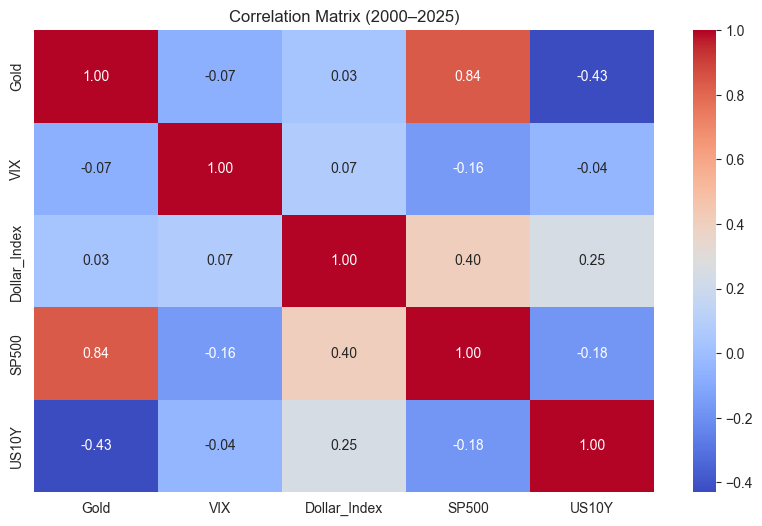

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------
# Load merged daily dataset
# ----------------------------------------------
data = pd.read_csv("data/merged_daily_data.csv")
data["Date"] = pd.to_datetime(data["Date"])
data = data.set_index("Date")

# Tes 5 variables finales
cols = ["Gold", "VIX", "Dollar_Index", "SP500", "US10Y"]

# ----------------------------------------------
# Table descriptive statistics : Mean + Variance
# ----------------------------------------------
desc_stats = pd.DataFrame({
    "Mean": data[cols].mean(),
    "Variance": data[cols].var()
})

print("\n📊  Descriptive Statistics (2000–2025) : Mean & Variance\n")
display(desc_stats.round(4))

# ----------------------------------------------
# Correlation heatmap
# ----------------------------------------------
plt.figure(figsize=(10,6))
sns.heatmap(data[cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (2000–2025)")
plt.show()


# - VIX analysis + Stress period detection + Crisis graphs

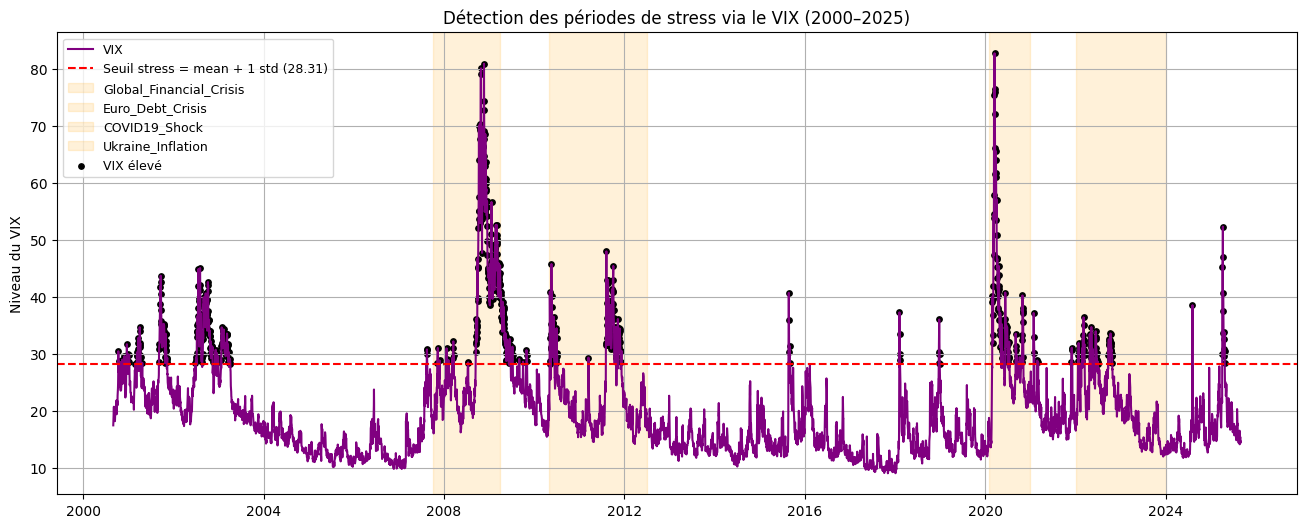

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("default")

# ---------------------------------------------------
# Charger le merged_daily_data.csv (valeurs brutes)
# ---------------------------------------------------
data = pd.read_csv("data/merged_daily_data.csv")
data["Date"] = pd.to_datetime(data["Date"])
data = data.set_index("Date")

# Vérifier présence du VIX brut
assert "VIX" in data.columns, "❌ Colonne VIX non trouvée dans merged_daily_data.csv"

vix = data["VIX"]

# ---------------------------------------------------
# 1) Détection des périodes de VIX élevé
# ---------------------------------------------------
vix_mean = vix.mean()
vix_std = vix.std()

# Seuil de stress : VIX > moyenne + 1 écart-type
threshold = vix_mean + vix_std
high_vix = vix > threshold

# ---------------------------------------------------
# 2) Définition des crises sélectionnées
# ---------------------------------------------------
crises = {
    "Global_Financial_Crisis": ("2007-10-01", "2009-03-31"),
    "Euro_Debt_Crisis": ("2010-05-01", "2012-06-30"),
    "COVID19_Shock": ("2020-02-01", "2020-12-31"),
    "Ukraine_Inflation": ("2022-01-01", "2023-12-31")
}

# ---------------------------------------------------
# 3) GRAPHIQUE : VIX + seuil + zones de crise
# ---------------------------------------------------
plt.figure(figsize=(16, 6))

# Ligne du VIX
plt.plot(vix.index, vix, label="VIX", color="purple")

# Seuil de stress
plt.axhline(threshold, color="red", linestyle="--",
            label=f"Seuil stress = mean + 1 std ({threshold:.2f})")

# Zones de crise
for crisis, (start, end) in crises.items():
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end),
                color="orange", alpha=0.15, label=crisis)

# Points où VIX > seuil
plt.scatter(vix.index[high_vix], vix[high_vix],
            color="black", s=15, label="VIX élevé")

plt.title("Détection des périodes de stress via le VIX (2000–2025)")
plt.ylabel("Niveau du VIX")
plt.legend(loc="upper left", fontsize=9)
plt.grid(True)

plt.show()

# 2) Descriptive analysis of the crises

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

# 1) Charger le fichier de rendements journaliers corrigés
returns = pd.read_csv("data/merged_daily_returns.csv")
returns["Date"] = pd.to_datetime(returns["Date"])
returns = returns.set_index("Date").dropna()

# Colonnes utilisées
ret_cols = ["Gold_Return", "SP500_Return",
            "Dollar_Index_Return", "US10Y_Return", "VIX_Return"]

# 2) Définition des crises post-2000
crises = {
    "Global_Financial_Crisis": ("2007-10-01", "2009-03-31"),
    "Euro_Debt_Crisis": ("2010-05-01", "2012-06-30"),
    "COVID19_Shock": ("2020-02-01", "2020-12-31"),
    "Ukraine_Inflation": ("2022-01-01", "2023-12-31"),
}

# 3) TABLEAU FINAL AVEC RETURNS JOURNALIERS
rows = []

for crisis, (start, end) in crises.items():
    sub = returns.loc[start:end]

    # Croissance cumulée = (1+r1)*(1+r2)*... - 1
    cum = (1 + sub[ret_cols]).prod() - 1

    # Volatilité journalière
    vol = sub[ret_cols].std()

    rows.append([
        crisis,
        cum["Gold_Return"] * 100,
        cum["SP500_Return"] * 100,
        cum["Dollar_Index_Return"] * 100,
        cum["US10Y_Return"] * 100,
        vol["Gold_Return"] * 100,
        vol["SP500_Return"] * 100,
        vol["Dollar_Index_Return"] * 100,
        vol["US10Y_Return"] * 100,
        ((1 + sub["VIX_Return"]).prod() - 1) * 100    # VIX cumul
    ])

# Construction du tableau
crisis_summary = pd.DataFrame(
    rows,
    columns=[
        "Crisis",
        "Gold_CumRet_%", "SP500_CumRet_%", "DXY_CumRet_%", "US10Y_CumRet_%",
        "Gold_Vol_%", "SP500_Vol_%", "DXY_Vol_%", "US10Y_Vol_%",
        "VIX_CumChange_%"
    ]
).set_index("Crisis")

print("\n📉 TABLEAU FINAL DES CRISES (Daily Returns corrigés) :\n")
display(crisis_summary.round(3))


📉 TABLEAU FINAL DES CRISES (Daily Returns corrigés) :



,Gold_CumRet_%,SP500_CumRet_%,DXY_CumRet_%,US10Y_CumRet_%,Gold_Vol_%,SP500_Vol_%,DXY_Vol_%,US10Y_Vol_%,VIX_CumChange_%
Crisis,,,,,,,,,
Global_Financial_Crisis,24.206,-47.741,9.920,56.793,1.862,2.414,0.717,8.786,145.222
Euro_Debt_Crisis,35.878,14.787,-0.269,139.236,1.193,1.275,0.555,6.422,-22.540
COVID19_Shock,19.597,16.449,-7.650,20.658,1.399,2.255,0.462,5.921,20.754
Ukraine_Inflation,12.854,0.077,5.916,-97.825,0.908,1.227,0.521,7.654,-27.700


# - CHARTS — cumulative growth (Gold / SP500 / DXY)

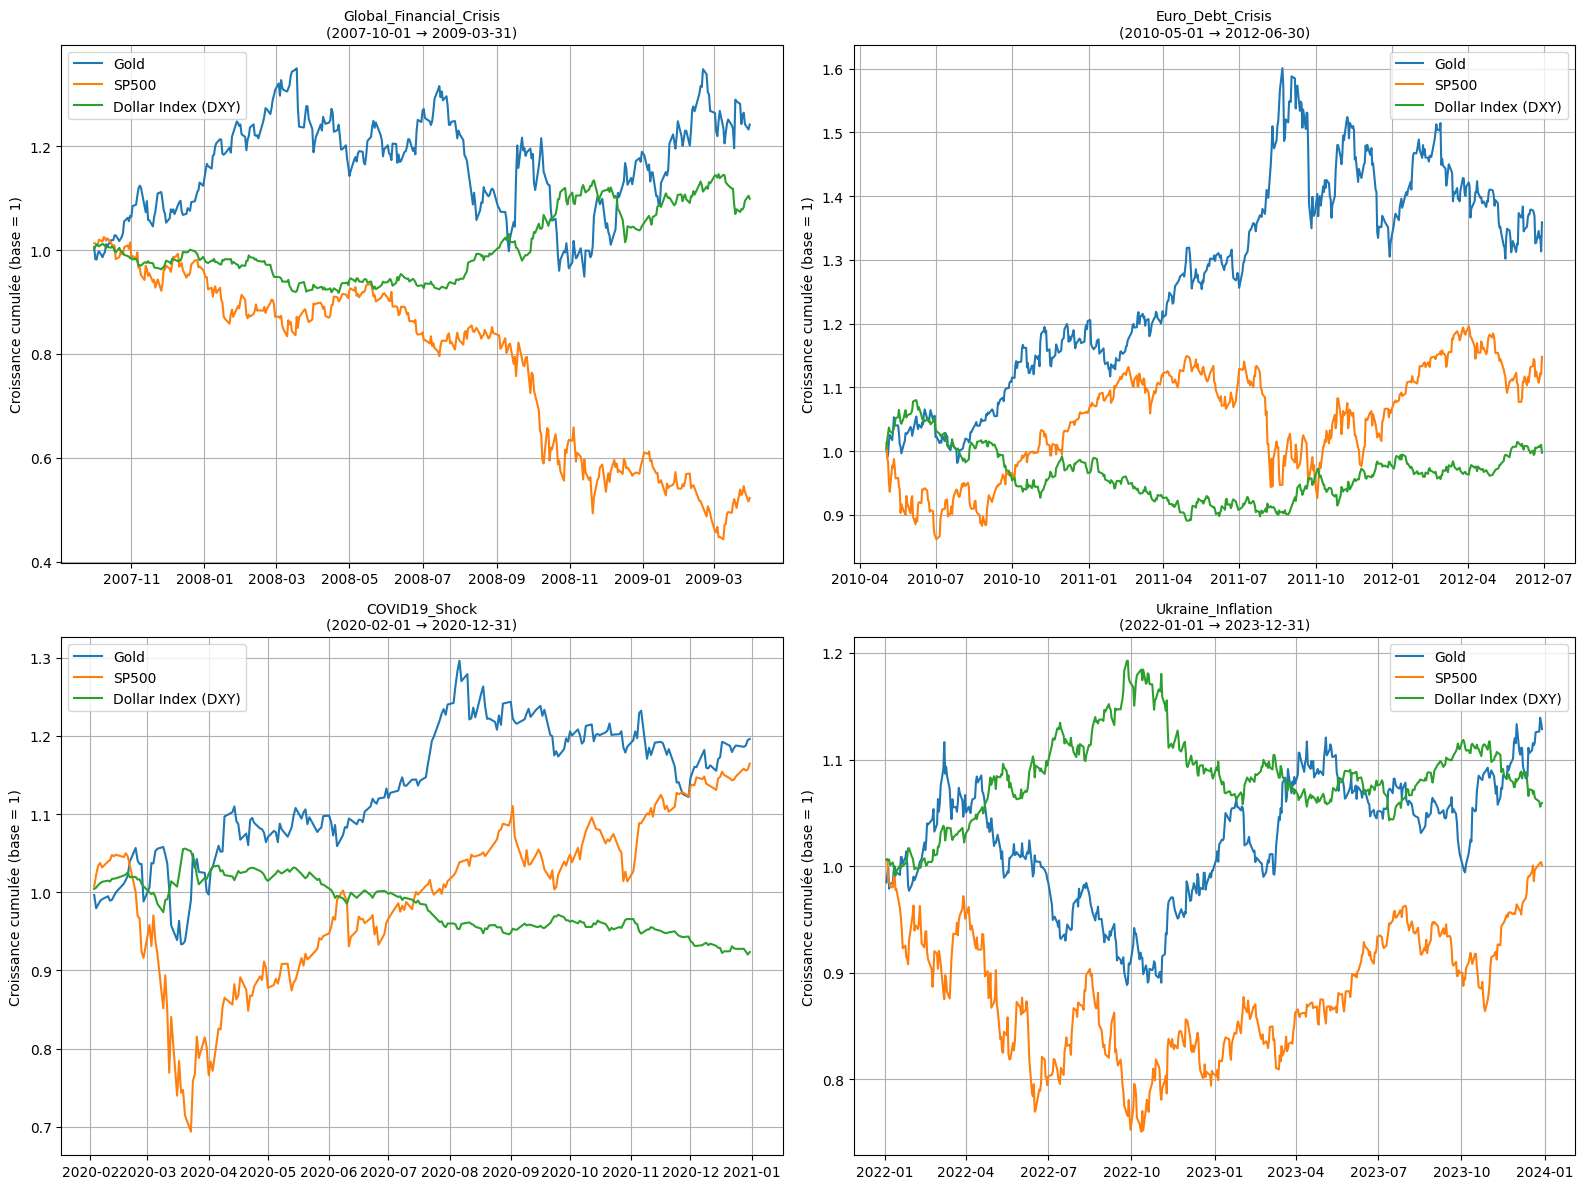

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")

# Charger les rendements journaliers
returns = pd.read_csv("data/merged_daily_returns.csv")
returns["Date"] = pd.to_datetime(returns["Date"])
returns = returns.set_index("Date")

# Fonction croissance cumulée
def cum_growth(r):
    return (1 + r).cumprod()

# Définition des 4 crises post-2000
crises = {
    "Global_Financial_Crisis": ("2007-10-01", "2009-03-31"),
    "Euro_Debt_Crisis": ("2010-05-01", "2012-06-30"),
    "COVID19_Shock": ("2020-02-01", "2020-12-31"),
    "Ukraine_Inflation": ("2022-01-01", "2023-12-31")
}

# Création des subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Boucle sur les crises
for ax, (crisis, (start, end)) in zip(axes, crises.items()):

    sub = returns.loc[start:end]

    ax.plot(sub.index, cum_growth(sub["Gold_Return"]), label="Gold")
    ax.plot(sub.index, cum_growth(sub["SP500_Return"]), label="SP500")
    ax.plot(sub.index, cum_growth(sub["Dollar_Index_Return"]), label="Dollar Index (DXY)")

    ax.set_title(f"{crisis}\n({start} → {end})", fontsize=10)
    ax.set_ylabel("Croissance cumulée (base = 1)")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


# Partie 1 - GLOBAL LINEAR REGRESSION

In [33]:
import pandas as pd
import statsmodels.api as sm

# Charger le fichier de returns corrigés
returns = pd.read_csv("data/merged_daily_returns.csv")
returns["Date"] = pd.to_datetime(returns["Date"])
returns = returns.set_index("Date").dropna()

# Liste des actifs à analyser
assets = {
    "Gold (Or)": "Gold_Return",
    "Dollar Index (DXY)": "Dollar_Index_Return",
    "US 10Y Treasury": "US10Y_Return"
}

results = []

for asset_name, y_col in assets.items():

    # Variable dépendante
    Y = returns[y_col]

    # Variable explicative unique : SP500
    X = returns[["SP500_Return"]]
    X = sm.add_constant(X)

    model = sm.OLS(Y, X).fit()

    beta = model.params["SP500_Return"]
    pval = model.pvalues["SP500_Return"]
    r2 = model.rsquared

    results.append([
        asset_name,
        beta,
        pval,
        r2
    ])

# Tableau final
global_reg_table = pd.DataFrame(
    results,
    columns=["Asset", "Beta_SP500", "Pvalue_SP500", "R_squared"]
)

print("\n📊 GLOBAL REGRESSION — Hedge Test (Corrected)\n")
display(global_reg_table.round(4))


📊 GLOBAL REGRESSION — Hedge Test (Corrected)



,Asset,Beta_SP500,Pvalue_SP500,R_squared
0,Gold (Or),-0.0048,0.6682,0.0000
1,Dollar Index (DXY),-0.0410,0.0000,0.0105
2,US 10Y Treasury,-1.3843,0.0000,0.0842


# Partie 2 Linéar Régression — Behavior during crises

In [3]:
# Partie 2 corrigée — Régressions par crise : uniquement vs S&P 500
import pandas as pd
import statsmodels.api as sm

returns = pd.read_csv("data/merged_daily_returns.csv")
returns['Date'] = pd.to_datetime(returns['Date'])
returns = returns.set_index("Date").dropna()

# Définition des crises (tes dates exactes)
crises = {
    "Global_Financial_Crisis": ("2007-10-01", "2009-03-31"),
    "Euro_Debt_Crisis": ("2010-05-01", "2012-06-30"),
    "COVID19_Shock": ("2020-02-01", "2020-12-31"),
    "Ukraine_Inflation": ("2022-01-01", "2023-12-31")
}

# Modèles : uniquement S&P 500 comme variable explicative
models = {
    "Gold (Or)": "Gold_Return",
    "Dollar Index (DXY)": "Dollar_Index_Return",
    "US 10Y Treasury": "US10Y_Return"
}

rows = []

for asset_name, y_col in models.items():
    for crisis_name, (start, end) in crises.items():
        sub = returns.loc[start:end]
        if len(sub) < 10:  # sécurité
            continue

        X = sm.add_constant(sub["SP500_Return"])
        y = sub[y_col]

        model = sm.OLS(y, X).fit()

        beta_sp500 = model.params["SP500_Return"]
        pval_sp500 = model.pvalues["SP500_Return"]

        rows.append({
            "Asset": asset_name,
            "Crisis": crisis_name,
            "Beta_SP500": round(beta_sp500, 4),
            "Pvalue_SP500": round(pval_sp500, 4),
            "R_squared": round(model.rsquared, 4)
        })

# Tableau final exactement comme le tien
crisis_reg_table = pd.DataFrame(rows, columns=["Asset", "Crisis", "Beta_SP500", "Pvalue_SP500", "R_squared"])
crisis_reg_table = crisis_reg_table.sort_values(["Asset", "Crisis"]).reset_index(drop=True)

print("\nCRISIS LINEAR REGRESSIONS — Behavior During Crises (vs S&P 500 only)\n")
display(crisis_reg_table.round(4))


CRISIS LINEAR REGRESSIONS — Behavior During Crises (vs S&P 500 only)



,Asset,Crisis,Beta_SP500,Pvalue_SP500,R_squared
0,Dollar Index (DXY),COVID19_Shock,-0.0044,0.7430,0.0005
1,Dollar Index (DXY),Euro_Debt_Crisis,-0.2261,0.0000,0.2698
2,Dollar Index (DXY),Global_Financial_Crisis,-0.0409,0.0074,0.0189
3,Dollar Index (DXY),Ukraine_Inflation,-0.1790,0.0000,0.1774
4,Gold (Or),COVID19_Shock,0.1156,0.0044,0.0347
5,Gold (Or),Euro_Debt_Crisis,0.0462,0.2491,0.0024
6,Gold (Or),Global_Financial_Crisis,-0.0477,0.2303,0.0038
7,Gold (Or),Ukraine_Inflation,0.0562,0.0896,0.0058
8,US 10Y Treasury,COVID19_Shock,-1.1320,0.0000,0.1858
9,US 10Y Treasury,Euro_Debt_Crisis,-2.8470,0.0000,0.3196


# Partie 3 Linéar regression — Safe haven test (quantiles) quand le s&p500 chute fortement

In [4]:
# Partie 3 — Safe Haven Test (Quantile Regression style Baur & Lucey 2010)
# UNIQUEMENT vs S&P 500 → version finale à mettre dans le mémoire

import pandas as pd
import statsmodels.api as sm

returns = pd.read_csv("data/merged_daily_returns.csv")
returns['Date'] = pd.to_datetime(returns['Date'])
returns = returns.set_index("Date").dropna()

# Actifs à tester
assets = {
    "Gold (Or)": "Gold_Return",
    "Dollar Index (DXY)": "Dollar_Index_Return",
    "US 10Y Treasury": "US10Y_Return"
}

quantiles = [0.01, 0.025, 0.05]   # 1%, 2.5%, 5% pires jours du S&P 500
rows = []

for asset_name, y_col in assets.items():
    y = returns[y_col]
    sp500 = returns["SP500_Return"]

    for q in quantiles:
        threshold = sp500.quantile(q)
        sp500_extreme = sp500.where(sp500 < threshold, 0)   # interaction

        X = pd.concat([sp500, sp500_extreme], axis=1)
        X.columns = ["SP500", "SP500_extreme"]
        X = sm.add_constant(X)

        model = sm.OLS(y, X).fit()

        beta_normal = model.params["SP500"]
        beta_extreme = model.params["SP500_extreme"]        # le coefficient clé
        total_beta_crash = beta_normal + beta_extreme

        p_normal = model.pvalues["SP500"]
        p_extreme = model.pvalues["SP500_extreme"]

        rows.append({
            "Asset": asset_name,
            "Quantile": f"{int(q*100)}%",
            "β normal": round(beta_normal, 4),
            "β extrême (ajout)": round(beta_extreme, 4),
            "β total en crash": round(total_beta_crash, 4),
            "p-value extrême": round(p_extreme, 4),
            "R²": round(model.rsquared, 4)
        })

# Tableau final parfait pour le mémoire
safehaven_table = pd.DataFrame(rows)
print("\nSAFE HAVEN TEST – Quantile approach (Baur & Lucey 2010)\n")
display(safehaven_table.round(4))


SAFE HAVEN TEST – Quantile approach (Baur & Lucey 2010)



,Asset,Quantile,β normal,β extrême (ajout),β total en crash,p-value extrême,R²
0,Gold (Or),1%,0.0014,-0.0338,-0.0323,0.2487,0.0002
1,Gold (Or),2%,0.0011,-0.0218,-0.0207,0.3996,0.0001
2,Gold (Or),5%,-0.0044,-0.0013,-0.0057,0.9567,0.0000
3,Dollar Index (DXY),1%,-0.0389,-0.0116,-0.0505,0.3731,0.0106
4,Dollar Index (DXY),2%,-0.0391,-0.0072,-0.0463,0.5347,0.0106
5,Dollar Index (DXY),5%,-0.0388,-0.0063,-0.0451,0.5659,0.0106
6,US 10Y Treasury,1%,-1.3835,-0.0040,-1.3875,0.9789,0.0842
7,US 10Y Treasury,2%,-1.3025,-0.2999,-1.6023,0.0233,0.0849
8,US 10Y Treasury,5%,-1.2389,-0.4133,-1.6522,0.0010,0.0858


# - Plot of the performance of major safe-haven assets during extreme S&P 500 declines (worst 5% days, 2000-2025)

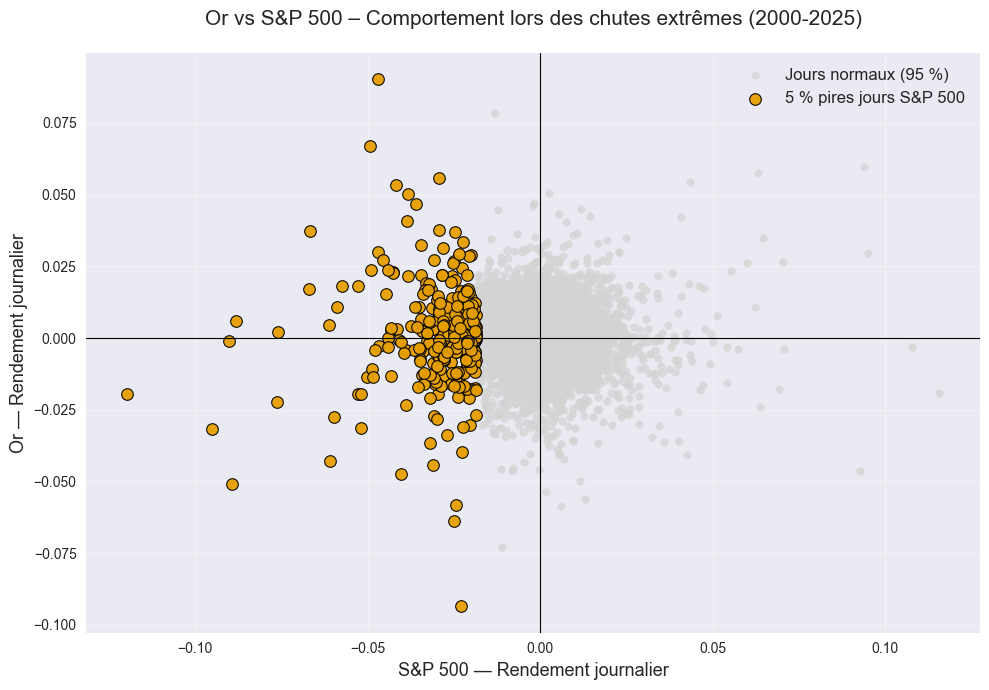

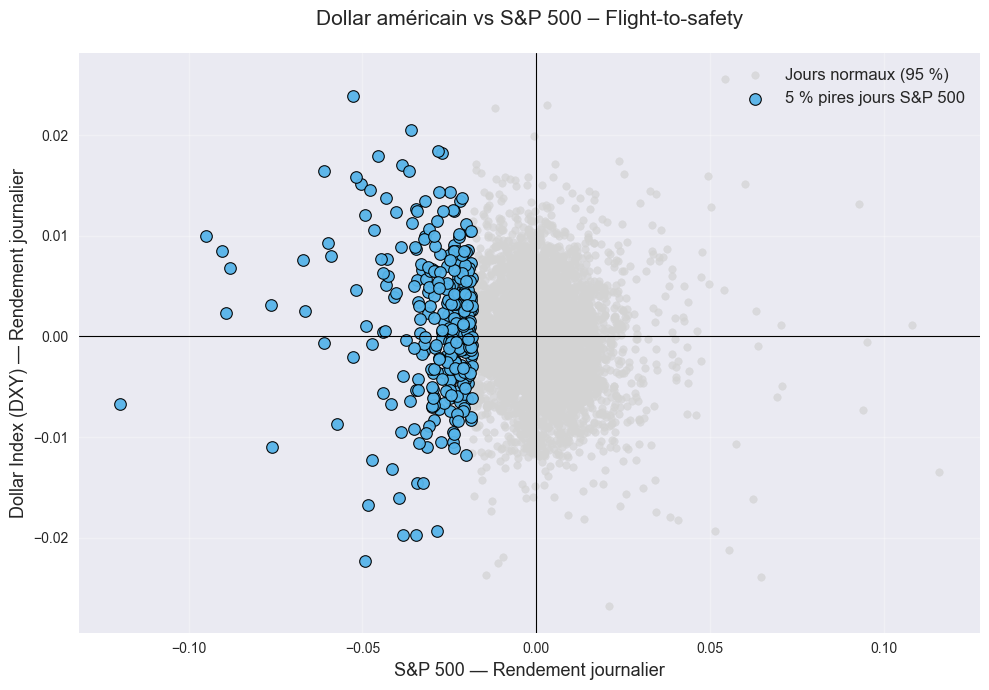

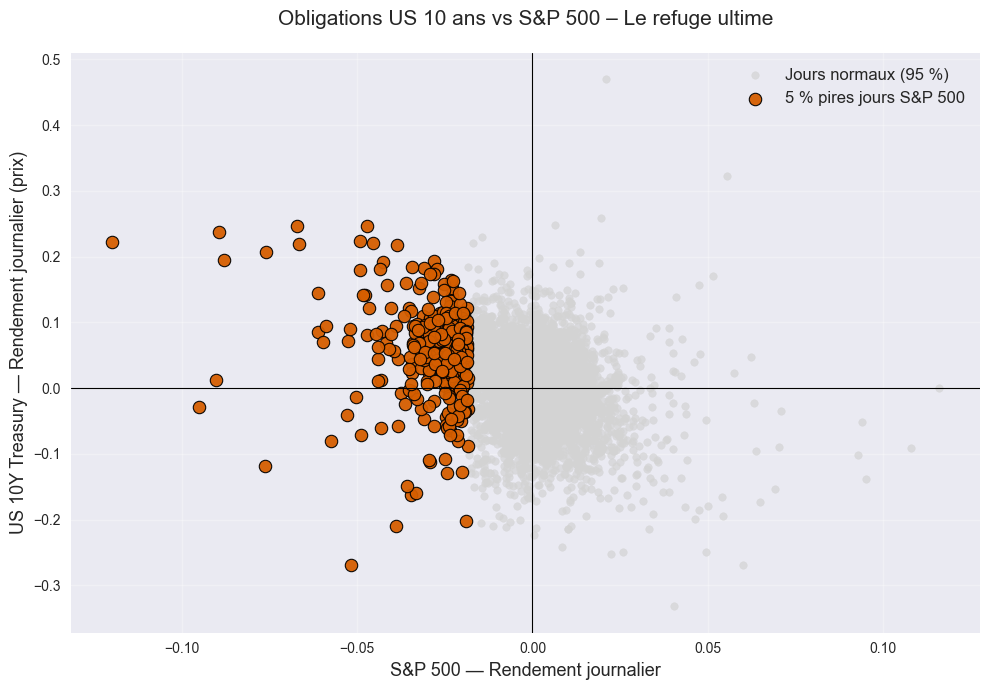

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correction de l'erreur de syntaxe
plt.style.use('seaborn-v0_8')          # correct
# ou si jamais tu as encore un souci :
# plt.style.use('seaborn')

# Sécurité
returns = returns.dropna()

# Quantile à mettre en évidence (change en 0.01 si tu veux les 1% les plus extrêmes)
q = 0.05
threshold = returns['SP500_Return'].quantile(q)
normal = returns['SP500_Return'] >= threshold
extreme = returns['SP500_Return'] < threshold

# =================================================
# 1) OR vs S&P 500
# =================================================
plt.figure(figsize=(10,7))
plt.scatter(returns.loc[normal, 'SP500_Return'], returns.loc[normal, 'Gold_Return'],
            c='lightgray', alpha=0.7, s=30, label='Jours normaux (95 %)')

plt.scatter(returns.loc[extreme, 'SP500_Return'], returns.loc[extreme, 'Gold_Return'],
            c='#E69F00', edgecolors='black', linewidth=0.8, s=70, alpha=0.95,
            label='5 % pires jours S&P 500')

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('S&P 500 — Rendement journalier', fontsize=13)
plt.ylabel('Or — Rendement journalier', fontsize=13)
plt.title('Or vs S&P 500 – Comportement lors des chutes extrêmes (2000-2025)', fontsize=15, pad=20)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =================================================
# 2) DOLLAR (DXY) vs S&P 500
# =================================================
plt.figure(figsize=(10,7))
plt.scatter(returns.loc[normal, 'SP500_Return'], returns.loc[normal, 'Dollar_Index_Return'],
            c='lightgray', alpha=0.7, s=30, label='Jours normaux (95 %)')

plt.scatter(returns.loc[extreme, 'SP500_Return'], returns.loc[extreme, 'Dollar_Index_Return'],
            c='#56B4E9', edgecolors='black', linewidth=0.8, s=70, alpha=0.95,
            label='5 % pires jours S&P 500')

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('S&P 500 — Rendement journalier', fontsize=13)
plt.ylabel('Dollar Index (DXY) — Rendement journalier', fontsize=13)
plt.title('Dollar américain vs S&P 500 – Flight-to-safety', fontsize=15, pad=20)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =================================================
# 3) US 10Y TREASURY vs S&P 500
# =================================================
plt.figure(figsize=(10,7))
plt.scatter(returns.loc[normal, 'SP500_Return'], returns.loc[normal, 'US10Y_Return'],
            c='lightgray', alpha=0.7, s=30, label='Jours normaux (95 %)')

plt.scatter(returns.loc[extreme, 'SP500_Return'], returns.loc[extreme, 'US10Y_Return'],
            c='#D55E00', edgecolors='black', linewidth=0.8, s=80, alpha=0.95,
            label='5 % pires jours S&P 500')

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('S&P 500 — Rendement journalier', fontsize=13)
plt.ylabel('US 10Y Treasury — Rendement journalier (prix)', fontsize=13)
plt.title('Obligations US 10 ans vs S&P 500 – Le refuge ultime', fontsize=15, pad=20)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()